<a href="https://colab.research.google.com/github/drmistretta/PredictCollege/blob/main/1012_Ladder_Frequency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<ipython-input-2-c78ea1db2724>:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([frequency_df, summary_df], ignore_index=False)


+---------+-------------+
| H5EC9   |   Frequency |
+=========+=============+
| Mean    |     5.50611 |
+---------+-------------+
| Mode    |     5       |
+---------+-------------+


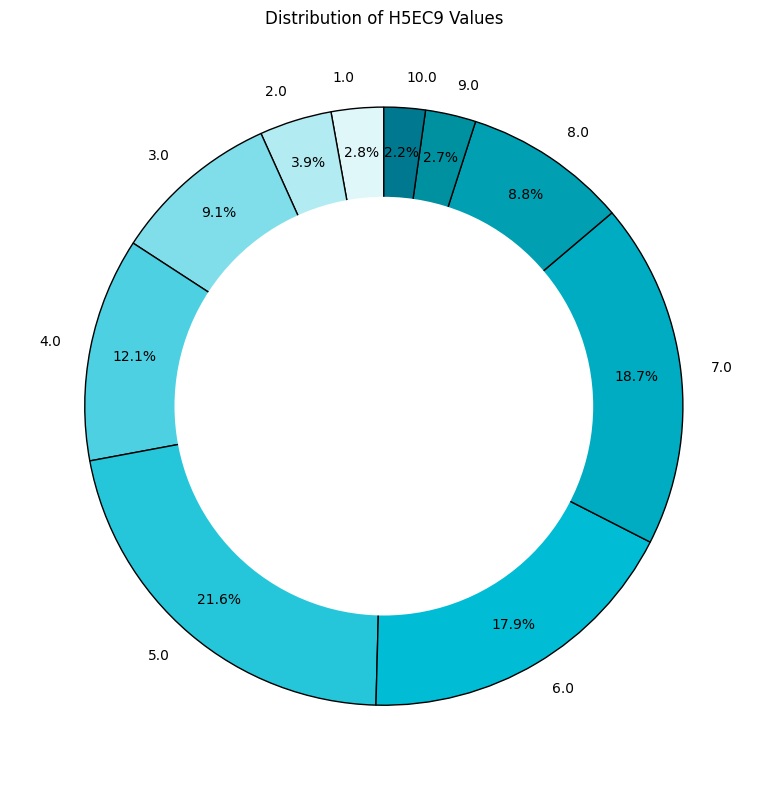

In [ ]:
!pip install tabulate
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# Reading the CSV file into a DataFrame
df = pd.read_csv('/content/drive/Shared drives/Dr. Sharon Mistretta/Add Health/Predict_College/data_with_birth_year.csv')

# Eliminating NaN values in H5EC9
df_cleaned = df.dropna(subset=['H5EC9'])

# Calculating frequency of each value in H5EC9
frequency_table = df_cleaned['H5EC9'].value_counts().sort_index()

# Calculating mean and mode for H5EC9
mean_value = df_cleaned['H5EC9'].mean()
mode_value = df_cleaned['H5EC9'].mode()[0]  # Mode can return multiple values, so we take the first one

# Creating a DataFrame from the frequency table
frequency_df = pd.DataFrame(frequency_table, columns=['Frequency'])

# Creating a DataFrame for mean and mode
summary_df = pd.DataFrame({
    'Frequency': [mean_value, mode_value]
}, index=['Mean', 'Mode'])

# Filling any potential NaN values in the summary_df (though they shouldn't exist here)
summary_df = summary_df.fillna(0)

# Concatenating the frequency table with the mean and mode
final_df = pd.concat([frequency_df, summary_df], ignore_index=False)

# Displaying the updated table using Tabulate
table = tabulate(final_df, headers=['H5EC9', 'Frequency'], tablefmt='grid')
print(table)

# Creating a pie chart for the frequency of H5EC9 values (excluding mean and mode)
colors = ['#e0f7fa', '#b2ebf2', '#80deea', '#4dd0e1', '#26c6da', '#00bcd4', '#00acc1', '#00a0b2', '#0091a1', '#00788f']
plt.figure(figsize=(8, 8))

# Showing all percentages, including small slices
def autopct_generator(pct):
    return '%1.1f%%' % pct  # Show all percentages

# Plotting the pie chart
plt.pie(frequency_table, labels=frequency_table.index, autopct=autopct_generator, startangle=90, colors=colors,
        wedgeprops={'edgecolor': 'black'}, pctdistance=0.85)

# Adding a circle at the center to create a donut chart for improved readability
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

# Adding title and ensuring the aspect ratio is equal
plt.title('Distribution of H5EC9 Values')
plt.tight_layout()
plt.show()
